# Logistic Regression from Scratch
---
**Author:** Hamna Munir  
**Repository:** ML-from-Scratch  
**Section:** Supervised Learning  

**Goal:** Learn how to implement logistic regression without libraries.

---

## Introduction

Logistic Regression is used for **binary classification** problems.

- Predicts probability of class 0 or 1
- Uses **Sigmoid function** to map predictions to probabilities
- Optimizes weights using **Gradient Descent**

## Sigmoid Function

The sigmoid function maps any real value into the range (0,1):

σ(z) = 1 / (1 + exp(-z))

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

### Example: Sigmoid Output

Check sigmoid values for some numbers.

In [3]:
print("Sigmoid([0, 2, -2]):", sigmoid(np.array([0, 2, -2])))

Sigmoid([0, 2, -2]): [0.5        0.88079708 0.11920292]


## Cost Function

Binary Cross-Entropy Loss:

L = -(y * log(p) + (1-y) * log(1-p))

In [4]:
def compute_loss(y, y_pred):
    m = y.shape[0]
    loss = -(1/m) * np.sum(y * np.log(y_pred + 1e-15) + (1 - y) * np.log(1 - y_pred + 1e-15))
    return loss

## Gradient Descent

Update weights to minimize loss:

w = w - learning_rate * dw
b = b - learning_rate * db

In [6]:
def gradient_descent(X, y, w, b, lr, iterations):
    m = X.shape[0]
    for i in range(iterations):
        z = np.dot(X, w) + b
        y_pred = sigmoid(z)
        dw = (1/m) * np.dot(X.T, (y_pred - y))
        db = (1/m) * np.sum(y_pred - y)
        w -= lr * dw
        b -= lr * db
        if i % 100 == 0:
            print(f"Iteration {i}, Loss: {compute_loss(y, y_pred):.4f}")
    return w, b

## Training Example

Create a simple dataset for binary classification.

In [7]:
# Simple dataset
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=500, n_features=2, n_informative=2, 
                           n_redundant=0, n_clusters_per_class=1, random_state=42)
w = np.zeros(X.shape[1])
b = 0
learning_rate = 0.1
iterations = 1000

In [8]:
w, b = gradient_descent(X, y, w, b, learning_rate, iterations)

Iteration 0, Loss: 0.6931
Iteration 100, Loss: 0.3468
Iteration 200, Loss: 0.3296
Iteration 300, Loss: 0.3246
Iteration 400, Loss: 0.3227
Iteration 500, Loss: 0.3218
Iteration 600, Loss: 0.3214
Iteration 700, Loss: 0.3212
Iteration 800, Loss: 0.3211
Iteration 900, Loss: 0.3211


## Prediction Function

In [9]:
def predict(X, w, b, threshold=0.5):
    y_pred = sigmoid(np.dot(X, w) + b)
    return (y_pred >= threshold).astype(int)

## Accuracy

In [10]:
y_pred = predict(X, w, b)
accuracy = np.mean(y_pred == y)
print("Accuracy:", accuracy)

Accuracy: 0.874


## Visualization

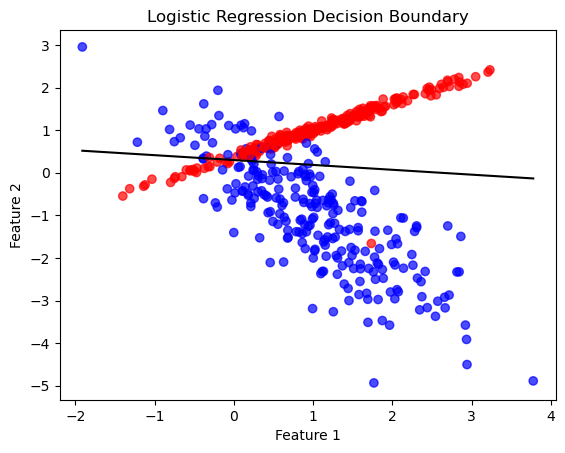

In [11]:
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', alpha=0.7)

# Plot decision boundary
x_values = np.array([X[:,0].min(), X[:,0].max()])
y_values = -(w[0]*x_values + b)/w[1]
plt.plot(x_values, y_values, color='black')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary')
plt.show()